# 02 — EDA: LMD-2023 Dataset

LMD-2023 contains raw Sysmon events across three size variants (1.75 M, 1.87 M, 2.3 M).  
Labels: **0 = Normal**, **1 = EoRS** (End-of-RansomwareSession), **2 = EoHT** (End-of-HardTarget).

Files are 1–1.5 GB — all analysis uses chunked/streaming reads.

**Goals:**
- Label distribution across all three variants
- Event type (EventID) distribution
- Top process images and command-line patterns
- Temporal event density
- Network connection analysis (EventID 3)
- Registry activity analysis (EventIDs 12–14)
- Class imbalance assessment and mitigation strategy
- Cross-variant comparison (1.75M / 1.87M / 2.3M)

In [1]:
import sys
sys.path.insert(0, r'h:\Challenge-3-4\cyber-anomaly-detection')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style='whitegrid')
%matplotlib inline

In [2]:
from data.ingest.lmd2023 import iter_chunks

VARIANT = '2.3M'   # change to '1.75M' or '1.87M' if needed
# no cap — full dataset

label_counts = Counter()
event_id_counts = Counter()
image_counts = Counter()
rows_seen = 0

for chunk in iter_chunks(variant=VARIANT):
    label_counts.update(chunk['label'].dropna().astype(int).tolist())
    event_id_counts.update(chunk['event_id'].dropna().astype(int).tolist())
    image_counts.update(
        chunk['image'].dropna()
             .str.split('\\').str[-1]   # basename only
             .str.lower().tolist()
    )
    rows_seen += len(chunk)

print(f'Rows processed: {rows_seen:,}')
print('Label counts:', dict(sorted(label_counts.items())))

Rows processed: 2,144,008
Label counts: {0: 1632903, 1: 375239, 2: 135866}


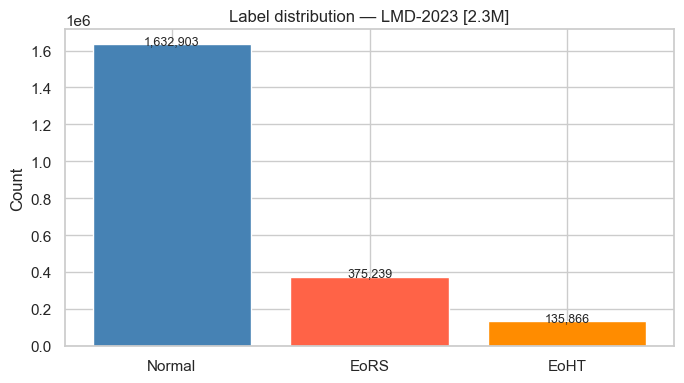

In [4]:
# Label distribution
label_map = {0: 'Normal', 1: 'EoRS', 2: 'EoHT'}
labels = [label_map.get(k, str(k)) for k in sorted(label_counts.keys())]
counts = [label_counts[k] for k in sorted(label_counts.keys())]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, counts, color=['steelblue', 'tomato', 'darkorange'])
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{cnt:,}', ha='center', fontsize=9)
ax.set_title(f'Label distribution — LMD-2023 [{VARIANT}]')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

F:\GECAD\_cache\tmp\ipykernel_13648\359597346.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=eid_df, x='count', y='name', ax=ax, palette='Blues_r')


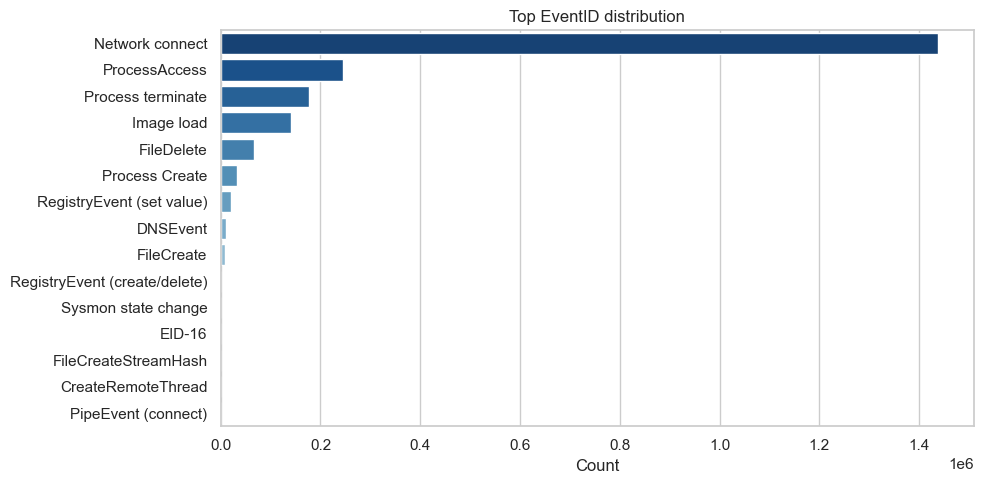

 EventID   count                          name
       3 1438284               Network connect
      10  244515                 ProcessAccess
       5  176169             Process terminate
       7  141392                    Image load
      23   66317                    FileDelete
       1   32453                Process Create
      13   21425     RegistryEvent (set value)
      22   10977                      DNSEvent
      11    9513                    FileCreate
      12     805 RegistryEvent (create/delete)
       4     456           Sysmon state change
      16     356                        EID-16
      15     338          FileCreateStreamHash
       8     335            CreateRemoteThread
      18     265           PipeEvent (connect)


In [5]:
# EventID distribution
eid_df = pd.DataFrame(event_id_counts.most_common(15), columns=['EventID', 'count'])
eid_map = {
    1: 'Process Create', 2: 'File creation time', 3: 'Network connect',
    4: 'Sysmon state change', 5: 'Process terminate', 6: 'Driver load',
    7: 'Image load', 8: 'CreateRemoteThread', 9: 'RawAccessRead',
    10: 'ProcessAccess', 11: 'FileCreate', 12: 'RegistryEvent (create/delete)',
    13: 'RegistryEvent (set value)', 14: 'RegistryEvent (rename)',
    15: 'FileCreateStreamHash', 17: 'PipeEvent (create)',
    18: 'PipeEvent (connect)', 22: 'DNSEvent', 23: 'FileDelete',
    25: 'ProcessTamper', 26: 'FileDeleteDetected',
}
eid_df['name'] = eid_df['EventID'].map(lambda x: eid_map.get(x, f'EID-{x}'))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=eid_df, x='count', y='name', ax=ax, palette='Blues_r')
ax.set_title('Top EventID distribution')
ax.set_xlabel('Count')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print(eid_df.to_string(index=False))

F:\GECAD\_cache\tmp\ipykernel_13648\1055205569.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=img_df, x='count', y='image', ax=ax, palette='rocket_r')


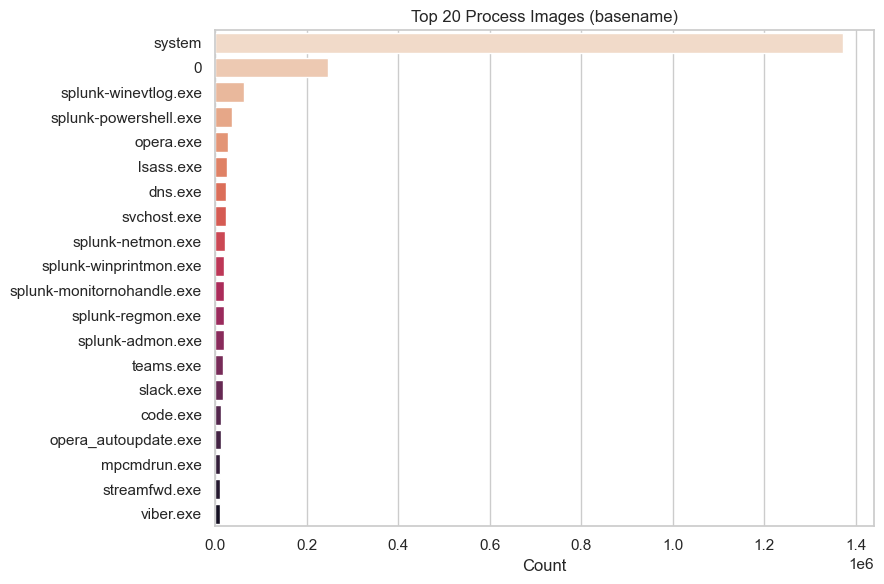

In [6]:
# Top 20 process images
img_df = pd.DataFrame(image_counts.most_common(20), columns=['image', 'count'])

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=img_df, x='count', y='image', ax=ax, palette='rocket_r')
ax.set_title('Top 20 Process Images (basename)')
ax.set_xlabel('Count')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

F:\GECAD\_cache\tmp\ipykernel_13648\3136315763.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_sample['utc_time'] = pd.to_datetime(df_sample['utc_time'], errors='coerce')


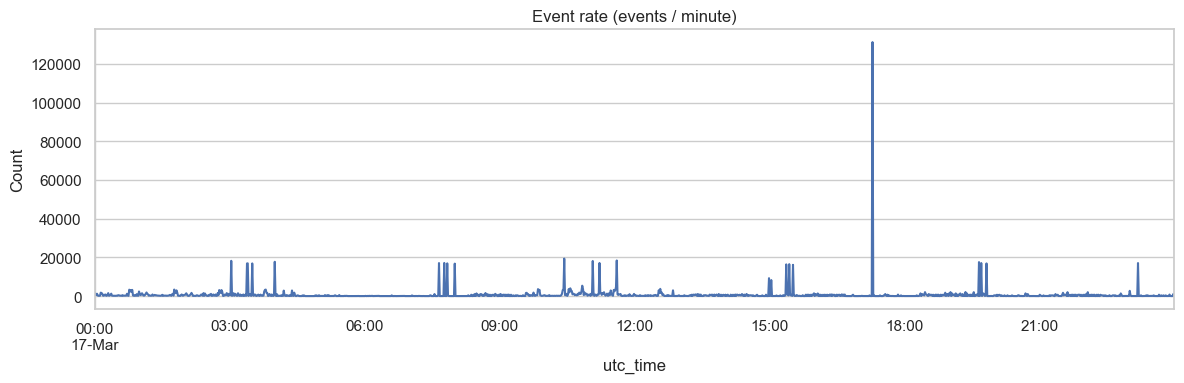

In [7]:
# Reload full dataset to inspect temporal density
from data.ingest.lmd2023 import load_full

df_sample = load_full(variant=VARIANT)

if 'utc_time' in df_sample.columns:
    df_sample['utc_time'] = pd.to_datetime(df_sample['utc_time'], errors='coerce')
    df_time = df_sample.set_index('utc_time').resample('1min').size()

    fig, ax = plt.subplots(figsize=(12, 4))
    df_time.plot(ax=ax)
    ax.set_title('Event rate (events / minute)')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print('No utc_time column found in this sample.')

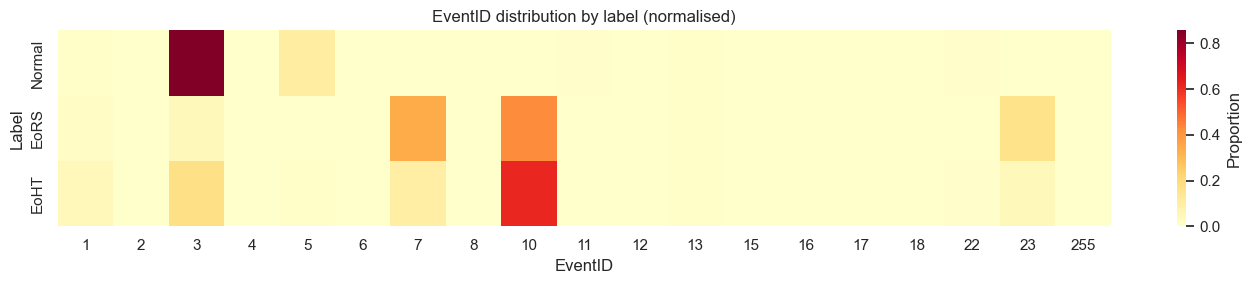

In [8]:
# Per-label EventID heatmap (proportional) — full dataset
df_small = load_full(variant=VARIANT)

pivot = (df_small
         .assign(event_id=df_small['event_id'].astype('Int64'))
         .groupby(['label', 'event_id'])
         .size()
         .unstack(fill_value=0))

# Normalise rows
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)
pivot_norm.index = pivot_norm.index.map(lambda x: label_map.get(x, str(x)))

fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(pivot_norm, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Proportion'})
ax.set_title('EventID distribution by label (normalised)')
ax.set_xlabel('EventID')
ax.set_ylabel('Label')
plt.tight_layout()
plt.show()

## Command-Line Analysis

Inspect command-line strings split by label to surface tokens that distinguish ransomware (EoRS) and APT-like activity (EoHT) from normal behaviour.  
A secondary scan checks for known LOLBin / suspicious keywords regardless of label.

Rows scanned: 2,144,008


F:\GECAD\_cache\tmp\ipykernel_13648\3408734055.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top, x='count', y='token', ax=ax, palette='Blues_r')
F:\GECAD\_cache\tmp\ipykernel_13648\3408734055.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top, x='count', y='token', ax=ax, palette='Blues_r')
F:\GECAD\_cache\tmp\ipykernel_13648\3408734055.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top, x='count', y='token', ax=ax, palette='Blues_r')


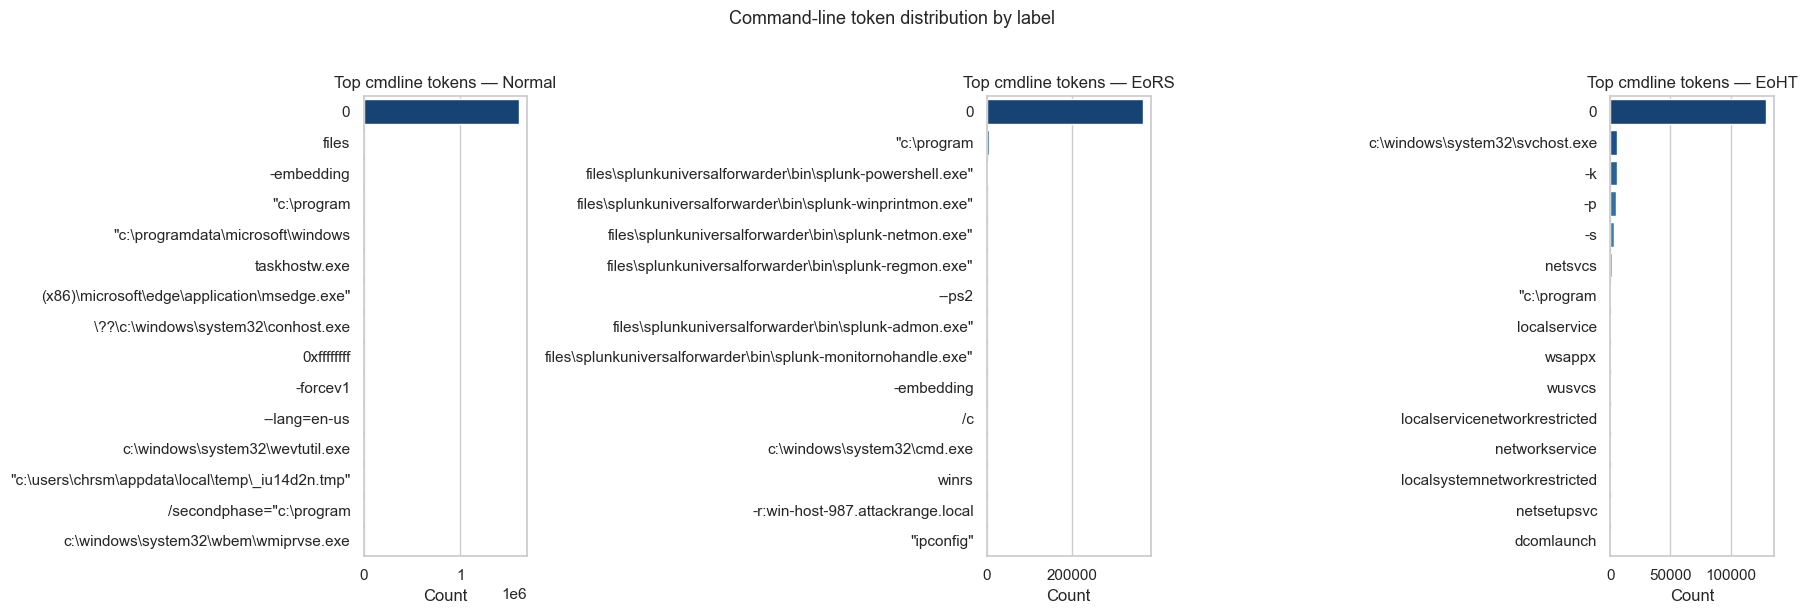

F:\GECAD\_cache\tmp\ipykernel_13648\3408734055.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=kw_df, x='hits', y='keyword', ax=ax, palette='Reds_r')


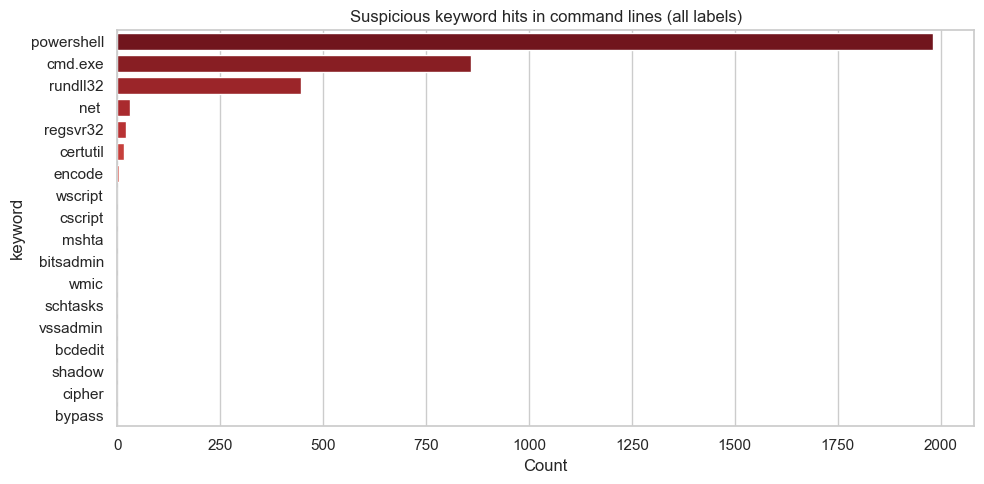

In [9]:
# no cap — full dataset
SUSPICIOUS_KEYWORDS = [
    'powershell', 'cmd.exe', 'wscript', 'cscript', 'mshta', 'rundll32',
    'regsvr32', 'certutil', 'bitsadmin', 'wmic', 'net ', 'schtasks',
    'vssadmin', 'bcdedit', 'shadow', 'cipher', 'encode', 'bypass',
]

cmdline_by_label = {0: Counter(), 1: Counter(), 2: Counter()}
keyword_hits = Counter()
rows_cmd = 0

for chunk in iter_chunks(variant=VARIANT):
    for lbl in [0, 1, 2]:
        mask = chunk['label'] == lbl
        tokens = (
            chunk.loc[mask, 'command_line']
            .dropna()
            .str.lower()
            .str.split()
            .explode()
            .dropna()
        )
        cmdline_by_label[lbl].update(tokens.tolist())

    cmdlines = chunk['command_line'].dropna().str.lower()
    for kw in SUSPICIOUS_KEYWORDS:
        keyword_hits[kw] += int(cmdlines.str.contains(kw, regex=False).sum())

    rows_cmd += len(chunk)

print(f'Rows scanned: {rows_cmd:,}')

# Top 15 cmdline tokens per label
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (lbl, name) in zip(axes, label_map.items()):
    top = pd.DataFrame(cmdline_by_label[lbl].most_common(15), columns=['token', 'count'])
    sns.barplot(data=top, x='count', y='token', ax=ax, palette='Blues_r')
    ax.set_title(f'Top cmdline tokens — {name}')
    ax.set_xlabel('Count')
    ax.set_ylabel('')
plt.suptitle('Command-line token distribution by label', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# Suspicious keyword frequency
kw_df = pd.DataFrame(keyword_hits.most_common(), columns=['keyword', 'hits'])
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=kw_df, x='hits', y='keyword', ax=ax, palette='Reds_r')
ax.set_title('Suspicious keyword hits in command lines (all labels)')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

## Network Connection Analysis (EventID 3)

Filter events with EventID = 3 (Network Connect) and inspect destination IPs, ports, and hostnames split by label.  
Ransomware typically beacons to C2 on non-standard ports; APT activity often uses legitimate-looking hostnames.

Network events: 1,438,284
label_name
Normal    1399345
EoHT        23374
EoRS        15565
Name: count, dtype: int64


F:\GECAD\_cache\tmp\ipykernel_13648\1261496066.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_ips,   x='count', y='dest_ip',   ax=axes[0], palette='Blues_r')
F:\GECAD\_cache\tmp\ipykernel_13648\1261496066.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_ports, x='count', y='dest_port', ax=axes[1], palette='Oranges_r')
F:\GECAD\_cache\tmp\ipykernel_13648\1261496066.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_hosts, x='count', y='hostname',  ax=axes[2], palette='Greens_r')


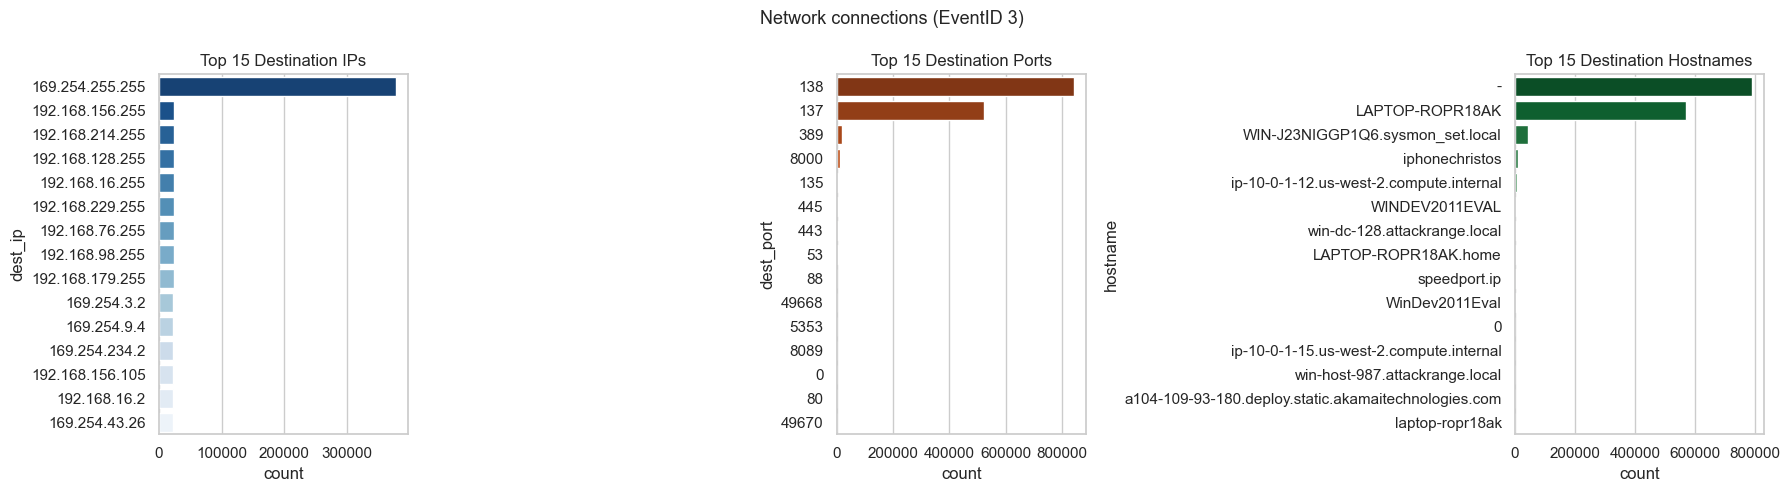

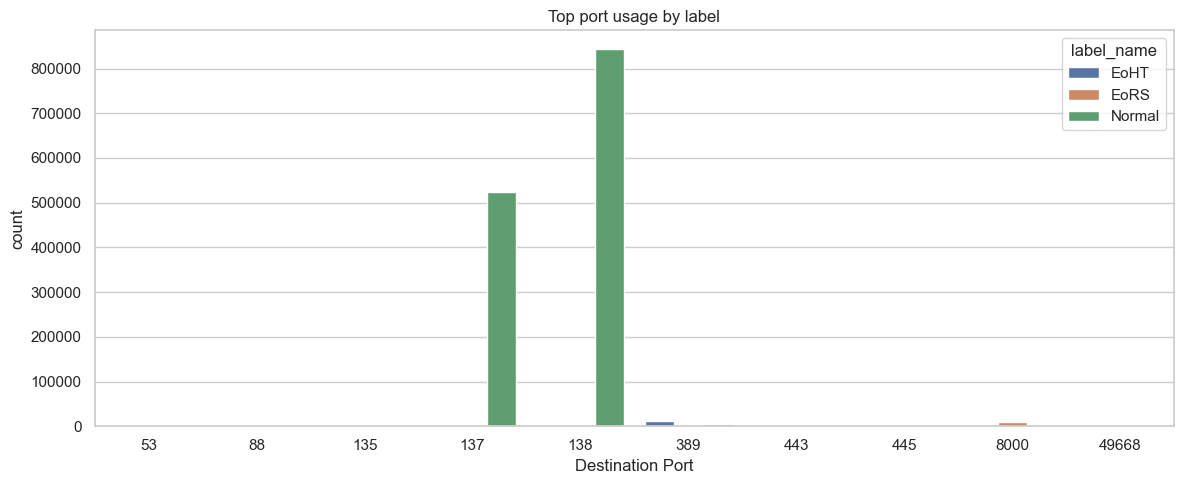

In [10]:
# no cap — full dataset
net_rows = []
rows_net = 0

for chunk in iter_chunks(variant=VARIANT):
    net = chunk[chunk['event_id'] == 3][
        ['label', 'dest_ip', 'dest_port', 'dest_hostname']
    ].copy()
    if not net.empty:
        net_rows.append(net)
    rows_net += len(chunk)

if net_rows:
    df_net = pd.concat(net_rows, ignore_index=True)
    df_net['label_name'] = df_net['label'].map(label_map)
    df_net['dest_port'] = pd.to_numeric(df_net['dest_port'], errors='coerce')
    print(f'Network events: {len(df_net):,}')
    print(df_net['label_name'].value_counts())

    top_ips    = df_net['dest_ip'].value_counts().head(15).reset_index()
    top_ips.columns = ['dest_ip', 'count']

    top_ports  = df_net['dest_port'].value_counts().head(15).reset_index()
    top_ports.columns = ['dest_port', 'count']
    top_ports['dest_port'] = top_ports['dest_port'].astype(str)

    top_hosts  = (df_net['dest_hostname']
                  .replace('', pd.NA).dropna()
                  .value_counts().head(15).reset_index())
    top_hosts.columns = ['hostname', 'count']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.barplot(data=top_ips,   x='count', y='dest_ip',   ax=axes[0], palette='Blues_r')
    axes[0].set_title('Top 15 Destination IPs')
    sns.barplot(data=top_ports, x='count', y='dest_port', ax=axes[1], palette='Oranges_r')
    axes[1].set_title('Top 15 Destination Ports')
    sns.barplot(data=top_hosts, x='count', y='hostname',  ax=axes[2], palette='Greens_r')
    axes[2].set_title('Top 15 Destination Hostnames')
    plt.suptitle('Network connections (EventID 3)', fontsize=13)
    plt.tight_layout()
    plt.show()

    # Port usage split by label
    top_port_vals = df_net['dest_port'].value_counts().head(10).index
    port_label = (df_net[df_net['dest_port'].isin(top_port_vals)]
                  .groupby(['label_name', 'dest_port'])
                  .size().reset_index(name='count'))
    port_label['dest_port'] = port_label['dest_port'].astype(str)

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(data=port_label, x='dest_port', y='count', hue='label_name', ax=ax)
    ax.set_title('Top port usage by label')
    ax.set_xlabel('Destination Port')
    plt.tight_layout()
    plt.show()
else:
    print('No EventID-3 (network) events in this sample.')

## Registry Analysis (EventIDs 12–14)

EventID 12 = create/delete key, 13 = set value, 14 = rename key.  
Ransomware commonly writes to `Run`/`RunOnce` persistence keys, disables `vssadmin` shadow copies, and modifies recovery/firewall settings.

Registry events: 22,230
event_id     12     13
label_name            
EoHT         80    916
EoRS         64   2758
Normal      661  17751


F:\GECAD\_cache\tmp\ipykernel_13648\2128805777.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_roots, x='count', y='reg_root', ax=axes[0], palette='Purples_r')


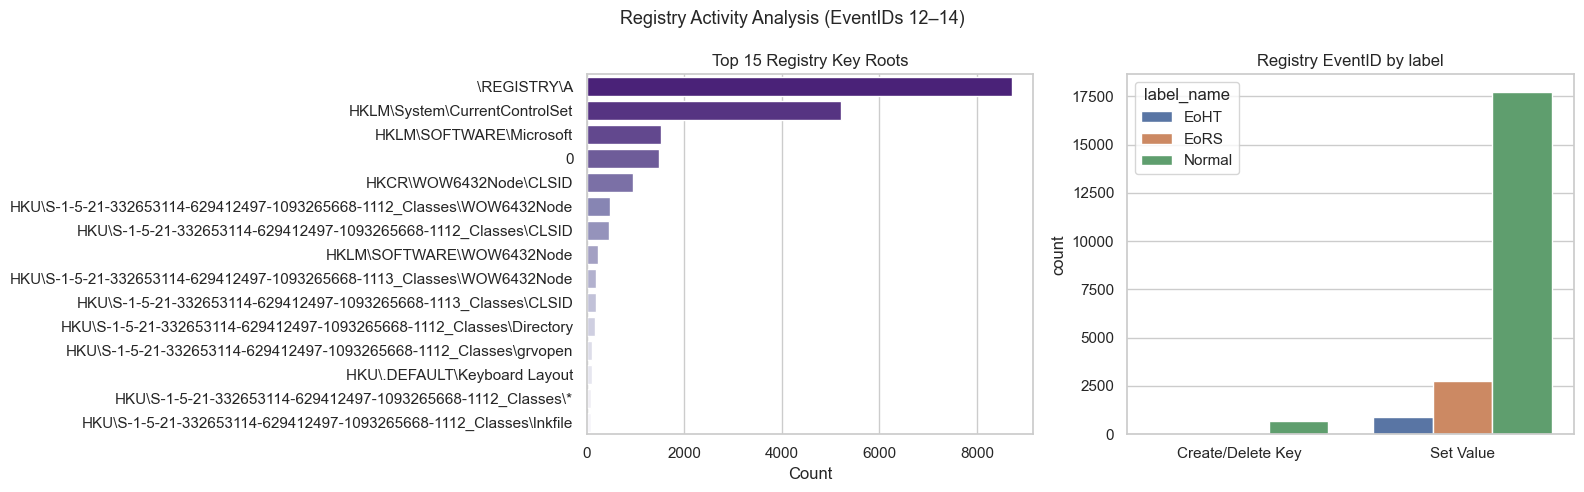


Suspicious registry key pattern hits:
  run                                : 652
  runonce                            : 18
  wbem                               : 213
  defender                           : 714
  firewall                           : 9


In [11]:
# no cap — full dataset
reg_rows = []
rows_reg = 0

for chunk in iter_chunks(variant=VARIANT):
    reg = chunk[chunk['event_id'].isin([12, 13, 14])][
        ['label', 'event_id', 'target_object', 'details']
    ].copy()
    if not reg.empty:
        reg_rows.append(reg)
    rows_reg += len(chunk)

if reg_rows:
    df_reg = pd.concat(reg_rows, ignore_index=True)
    df_reg['label_name'] = df_reg['label'].map(label_map)
    print(f'Registry events: {len(df_reg):,}')
    print(df_reg.groupby(['label_name', 'event_id']).size().unstack(fill_value=0))

    # Top registry key root paths (first 3 components)
    df_reg['reg_root'] = (
        df_reg['target_object']
        .str.split('\\')
        .str[:3]
        .str.join('\\')
    )
    top_roots = df_reg['reg_root'].value_counts().head(15).reset_index()
    top_roots.columns = ['reg_root', 'count']

    eid_label = df_reg.groupby(['label_name', 'event_id']).size().reset_index(name='count')
    eid_label['event_id'] = eid_label['event_id'].map(
        {12: 'Create/Delete Key', 13: 'Set Value', 14: 'Rename Key'}
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.barplot(data=top_roots, x='count', y='reg_root', ax=axes[0], palette='Purples_r')
    axes[0].set_title('Top 15 Registry Key Roots')
    axes[0].set_xlabel('Count')
    axes[0].set_ylabel('')

    sns.barplot(data=eid_label, x='event_id', y='count', hue='label_name', ax=axes[1])
    axes[1].set_title('Registry EventID by label')
    axes[1].set_xlabel('')
    plt.suptitle('Registry Activity Analysis (EventIDs 12–14)', fontsize=13)
    plt.tight_layout()
    plt.show()

    # Suspicious registry key patterns
    SUSPICIOUS_REG = [
        'run', 'runonce', 'shadow', 'recovery', 'currentversion\\policies',
        'safeboot', 'wbem', 'defender', 'firewall',
    ]
    df_reg['target_lower'] = df_reg['target_object'].str.lower()
    print('\nSuspicious registry key pattern hits:')
    for pattern in SUSPICIOUS_REG:
        hits = df_reg['target_lower'].str.contains(pattern, regex=False).sum()
        if hits:
            print(f'  {pattern:35s}: {hits:,}')
else:
    print('No registry events (12/13/14) found in this sample.')

## Class Imbalance Assessment & Strategy

Compute exact class ratios across the full variant and derive inverse-frequency weights for training.  
These weights are passed directly to sklearn estimators via `class_weight` and to PyTorch loss functions via `weight` tensor.

Full label distribution:
  Normal  :  1,632,903  (76.16%)
  EoRS    :    375,239  (17.50%)
  EoHT    :    135,866  (6.34%)

Suggested class_weight dict (sklearn convention):
  0 (Normal): 0.4377
  1 (EoRS): 1.9046
  2 (EoHT): 5.2601


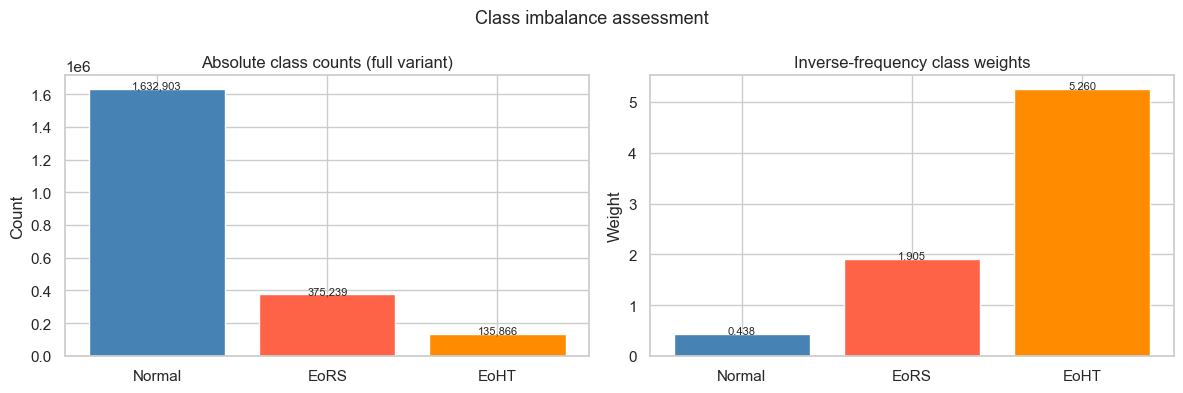


Imbalance ratio: 12.0x
  → Use class_weight + consider oversampling minority class (SMOTE/ADASYN).


In [12]:
# Full-pass label count (streaming — no RAM cap)
full_label_counts = Counter()
for chunk in iter_chunks(variant=VARIANT):
    full_label_counts.update(chunk['label'].dropna().astype(int).tolist())

total = sum(full_label_counts.values())
print('Full label distribution:')
for lbl, name in label_map.items():
    cnt = full_label_counts.get(lbl, 0)
    print(f'  {name:8s}: {cnt:>10,}  ({100*cnt/total:.2f}%)')

# Class weights (inverse frequency, normalised to n_classes)
n_classes = len(label_map)
class_weights = {
    lbl: total / (n_classes * full_label_counts.get(lbl, 1))
    for lbl in label_map
}
print('\nSuggested class_weight dict (sklearn convention):')
for lbl, name in label_map.items():
    print(f'  {lbl} ({name}): {class_weights[lbl]:.4f}')

# Visualise imbalance vs weights
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts_vals  = [full_label_counts.get(k, 0) for k in sorted(label_map)]
weights_vals = [class_weights[k] for k in sorted(label_map)]
names        = [label_map[k] for k in sorted(label_map)]
colors       = ['steelblue', 'tomato', 'darkorange']

axes[0].bar(names, counts_vals, color=colors)
axes[0].set_title('Absolute class counts (full variant)')
axes[0].set_ylabel('Count')
for p, cnt in zip(axes[0].patches, counts_vals):
    axes[0].text(p.get_x() + p.get_width()/2, p.get_height() + 200,
                 f'{cnt:,}', ha='center', fontsize=8)

axes[1].bar(names, weights_vals, color=colors)
axes[1].set_title('Inverse-frequency class weights')
axes[1].set_ylabel('Weight')
for p, w in zip(axes[1].patches, weights_vals):
    axes[1].text(p.get_x() + p.get_width()/2, p.get_height() + 0.001,
                 f'{w:.3f}', ha='center', fontsize=8)

plt.suptitle('Class imbalance assessment', fontsize=13)
plt.tight_layout()
plt.show()

max_ratio = max(counts_vals) / (min(c for c in counts_vals if c > 0))
print(f'\nImbalance ratio: {max_ratio:.1f}x')
if max_ratio > 10:
    print('  → Use class_weight + consider oversampling minority class (SMOTE/ADASYN).')
else:
    print('  → class_weight alone should suffice.')

## Cross-Variant Comparison

Compare label distributions and EventID profiles across the three LMD-2023 size variants to validate consistency before combining them into a single training corpus.

1.75M: 1,752,836 rows — labels {0: 1611619, 1: 110710, 2: 30507}
1.87M: 1,901,979 rows — labels {0: 1611619, 1: 234813, 2: 55547}
2.3M: 2,144,008 rows — labels {0: 1632903, 2: 135866, 1: 375239}


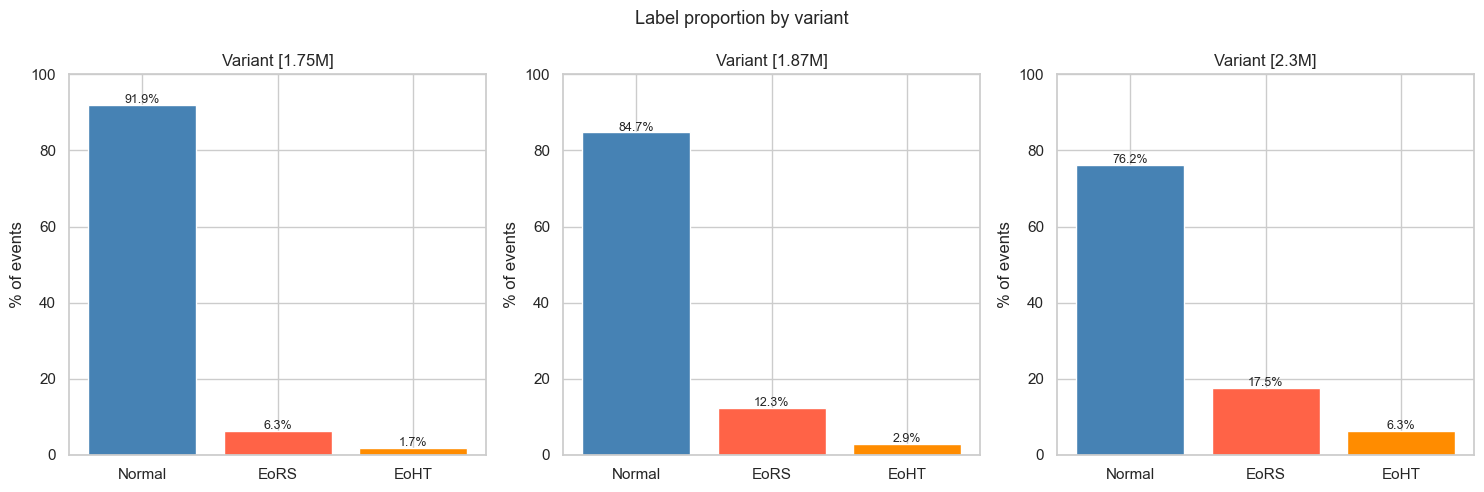

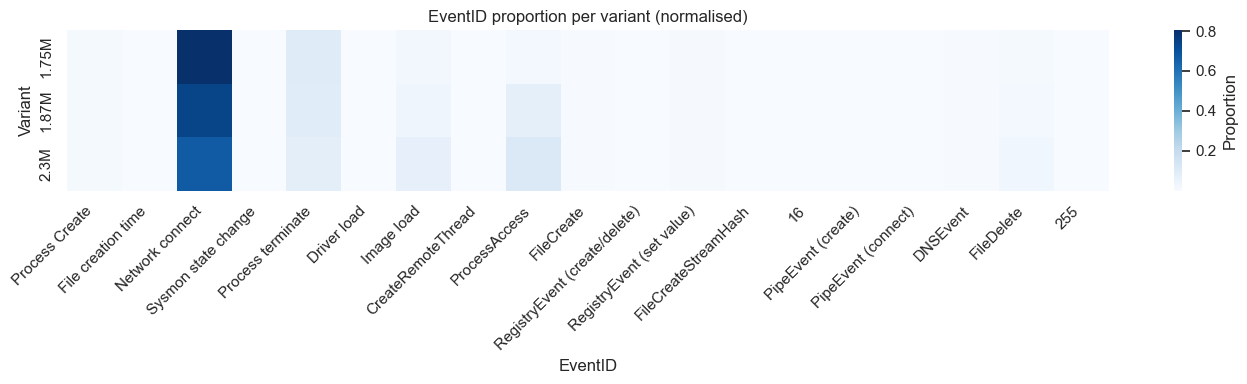

In [13]:
from data.ingest.lmd2023 import LMD_LABEL_NORMAL, LMD_LABEL_EORS, LMD_LABEL_EOHT

VARIANTS = ['1.75M', '1.87M', '2.3M']
# no cap — full dataset per variant

variant_stats = {}

for var in VARIANTS:
    lc = Counter()
    ec = Counter()
    rows = 0
    try:
        for chunk in iter_chunks(variant=var):
            lc.update(chunk['label'].dropna().astype(int).tolist())
            ec.update(chunk['event_id'].dropna().astype(int).tolist())
            rows += len(chunk)
        variant_stats[var] = {'labels': lc, 'events': ec, 'rows': rows}
        print(f'{var}: {rows:,} rows — labels {dict(lc)}')
    except FileNotFoundError as e:
        print(f'{var}: NOT FOUND — {e}')

# Label proportion comparison
fig, axes = plt.subplots(1, len(variant_stats), figsize=(5 * len(variant_stats), 5))
if len(variant_stats) == 1:
    axes = [axes]
for ax, (var, stats) in zip(axes, variant_stats.items()):
    lc = stats['labels']
    total_v = sum(lc.values()) or 1
    names_v = [label_map.get(k, str(k)) for k in sorted(lc)]
    pcts = [100 * lc[k] / total_v for k in sorted(lc)]
    ax.bar(names_v, pcts, color=['steelblue', 'tomato', 'darkorange'][:len(names_v)])
    ax.set_title(f'Variant [{var}]')
    ax.set_ylabel('% of events')
    ax.set_ylim(0, 100)
    for bar, pct in zip(ax.patches, pcts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{pct:.1f}%', ha='center', fontsize=9)
plt.suptitle('Label proportion by variant', fontsize=13)
plt.tight_layout()
plt.show()

# EventID overlap across variants
all_eids = sorted(set().union(*[s['events'].keys() for s in variant_stats.values()]))
eid_matrix = pd.DataFrame(
    {var: [variant_stats[var]['events'].get(eid, 0) for eid in all_eids]
     for var in variant_stats},
    index=all_eids
)
eid_matrix_norm = eid_matrix.div(eid_matrix.sum(axis=0))

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(eid_matrix_norm.T, cmap='Blues', ax=ax,
            xticklabels=[eid_map.get(e, str(e)) for e in all_eids],
            cbar_kws={'label': 'Proportion'})
ax.set_title('EventID proportion per variant (normalised)')
ax.set_xlabel('EventID')
ax.set_ylabel('Variant')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()